In [154]:
from pathlib import Path
import pandas as pd

base_dir = Path().resolve()
file_path = base_dir.parent / 'data' / 'medicare_data_cleaned.parquet'

if not file_path.exists():
    print(f"File not found: {file_path}")
    print("Files in directory:", list(file_path.parent.glob("*")))
else:
    df = pd.read_parquet(file_path)

In [155]:
X = df.drop(
    columns=['Tot_Dschrgs', 'Avg_Submtd_Cvrd_Chrg', 'Avg_Tot_Pymt_Amt', 'Avg_Mdcr_Pymt_Amt', 'Rndrng_Prvdr_St', 'Rndrng_Prvdr_State_FIPS'], axis=1)

y = df['Avg_Mdcr_Pymt_Amt']

In [156]:
cols = ['Rndrng_Prvdr_CCN', 'Rndrng_Prvdr_City', 'Rndrng_Prvdr_Zip5', 'DRG_Cd', 'Rndrng_Prvdr_Org_Name']
dummies_cols = ['Rndrng_Prvdr_State_Abrvtn', 'RUCA_category']

for col in cols:
    freq_map = X[col].value_counts() / len(X)
    X[col + '_encoded'] = X[col].map(freq_map)
    
freq_encoded_cols = [col + '_encoded' for col in cols]

X_dummies = pd.get_dummies(X[dummies_cols])
X_encoded = pd.concat([X[freq_encoded_cols], X_dummies], axis=1)
X_encoded.head()

,Rndrng_Prvdr_CCN_encoded,Rndrng_Prvdr_City_encoded,Rndrng_Prvdr_Zip5_encoded,DRG_Cd_encoded,Rndrng_Prvdr_Org_Name_encoded,Rndrng_Prvdr_State_Abrvtn_AK,Rndrng_Prvdr_State_Abrvtn_AL,Rndrng_Prvdr_State_Abrvtn_AR,Rndrng_Prvdr_State_Abrvtn_AZ,Rndrng_Prvdr_State_Abrvtn_CA,...,RUCA_category_micro_core,RUCA_category_micro_high_commute,RUCA_category_micro_low_commute,RUCA_category_rural,RUCA_category_secondary_flow_metro,RUCA_category_secondary_flow_micro,RUCA_category_small_town_core,RUCA_category_small_town_high_commute,RUCA_category_small_town_low_commute,RUCA_category_unknown
0,0.000682,0.001159,0.000682,0.002810,0.000682,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0.000682,0.001159,0.000682,0.001024,0.000682,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0.000682,0.001159,0.000682,0.003936,0.000682,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,0.000682,0.001159,0.000682,0.001488,0.000682,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0.000682,0.001159,0.000682,0.003278,0.000682,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [157]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, train_size=0.8)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


def metrics(y_prediction):
    y_true = y_test
    mae = mean_absolute_error(y_true=y_test, y_pred=y_prediction)
    mse = mean_squared_error(y_true=y_test, y_pred=y_prediction)  
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true=y_test, y_pred=y_prediction)

    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print('R2:', r2)

def plot(y_prediction):
    y_true = y_test 
    plt.scatter(y_test, y_prediction, color='b', alpha=0.2)
    plt.xlabel("Actual Avg_Mdcr_Pymt_Amt")
    plt.ylabel("Predicted Avg_Mdcr_Pymt_Amt")
    plt.title("Actual vs Predicted Medicare Payment Amount")
    plt.plot([y_test.min(), y_test.max()], [y_test.min(),
            y_test.max()], 'k--', lw=2)  
    plt.show()


MAE: 9204.14840413396
MSE: 300172863.8151229
RMSE: 17325.497505558764
R2: 0.09738978386466246


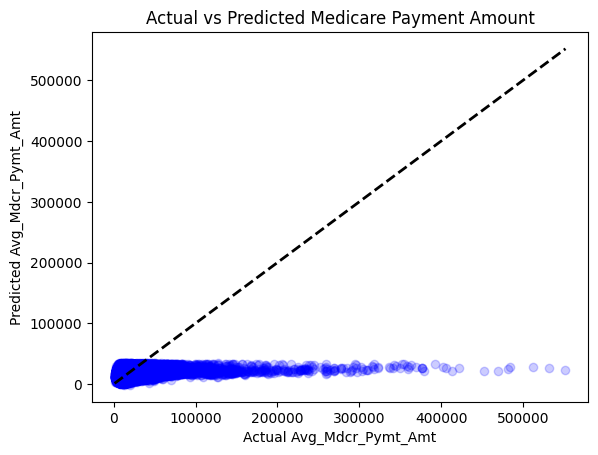

In [ ]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

metrics(y_pred)
plot(y_pred)

In [160]:
from sklearn.linear_model import Lasso, Ridge, ElasticNet

model = Lasso(alpha=1)
model.fit(X_train,y_train)
y_pred_lasso = model.predict(X_test)

metrics(y_pred_lasso)

MAE: 9173.45196442978
MSE: 300801878.7887715
RMSE: 17343.640874648307
R2: 0.09549835592510336


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 10, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
MAE: 2068.804084875942
MSE: 45018925.1750305
RMSE: 6709.614383482146
R2: 0.8646295295785239
None


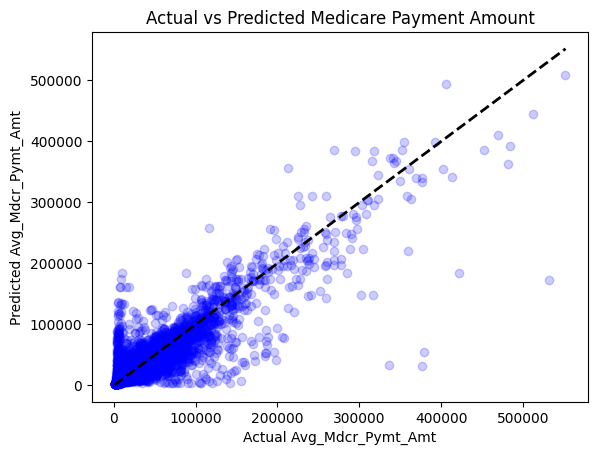

None


In [163]:
best_params = rf.get_params()
print(best_params)
print(metrics(y_pred_rf))
print(plot(y_pred_rf))